# 08 · Segmentation Model v3 — SAM Refinement + UNet++

Cải tiến so với notebook 07 (v2):
- **SAM Refinement**: Segment Anything Model (ViT-B) refine pseudo-labels v2 → boundary chính xác hơn
  - Extract centroid + sampled FG points + BG negative points từ mỗi mask
  - IoU guard: fallback về GradCAM++ nếu SAM drift (overlap < 0.15)
  - Post-process: CC filter + morphological close để loại noise
  - Kết quả lưu vào `sam_refined_labels_v3_train/` (resume được nếu bị ngắt)
- **Model**: UNet++ EfficientNet-B0 (giống v2 — so sánh công bằng, chỉ thay labels)
- **Loss / Optimizer**: FocalDice + AdamW + CosineAnnealing (giống v2)
- **Benchmark**: V1 vs V2 vs V3 cuối notebook

**Output**: `visualizations/segmentation_v3/`

In [1]:
import subprocess, sys

def ensure_installed(pip_name, import_name=None):
    import_name = import_name or pip_name.replace('-', '_')
    try:
        __import__(import_name)
        print(f'[OK] {pip_name}')
    except ImportError:
        print(f'Installing {pip_name}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pip_name, '-q'])
        print(f'[Installed] {pip_name}')

ensure_installed('segment-anything', 'segment_anything')
ensure_installed('segmentation-models-pytorch', 'segmentation_models_pytorch')
ensure_installed('albumentations')

[OK] segment-anything
[OK] segmentation-models-pytorch
[OK] albumentations


In [2]:
import os, sys, json, urllib.request

proj_root = r'e:\Master\thesis-clean'
sys.path.insert(0, proj_root)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from PIL import Image
from torch.utils.data import Dataset, DataLoader, Subset

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from segment_anything import sam_model_registry, SamPredictor

plt.style.use('default')
sns.set_palette("husl")

CLASS_NAMES  = ["ALGAL_LEAF_SPOT","ALLOCARIDARA_ATTACK","HEALTHY_LEAF","LEAF_BLIGHT","PHOMOPSIS_LEAF_SPOT"]
CLASS_LABELS = ["Algal Leaf Spot","Allocaridara Attack","Healthy Leaf","Leaf Blight","Phomopsis Leaf Spot"]
CLASS_COLORS = ["#E69F00","#56B4E9","#009E73","#0072B2","#D55E00"]
CLASS_TO_IDX = {name: i for i, name in enumerate(CLASS_NAMES)}
IDX_TO_LABEL = {i: label for i, label in enumerate(CLASS_LABELS)}

VIZ_DIR = os.path.join(proj_root, "visualizations", "segmentation_v3")
os.makedirs(VIZ_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('proj_root:', proj_root)
print('VIZ_DIR  :', VIZ_DIR)

device: cuda
proj_root: e:\Master\thesis-clean
VIZ_DIR  : e:\Master\thesis-clean\visualizations\segmentation_v3


## 1) SAM Setup — tải checkpoint & load model

**Reasoning**: SAM ViT-B (~375MB) là vision foundation model cho zero-shot segmentation. Dùng point prompts (centroid + sampled FG + BG negative) thay vì bbox để kiểm soát tốt hơn vùng được segment. IoU guard (min_iou=0.15) tránh trường hợp SAM "drift" sang object khác.

In [3]:
SAM_CKPT_DIR  = os.path.join(proj_root, 'notebooks', 'models', 'sam')
os.makedirs(SAM_CKPT_DIR, exist_ok=True)

SAM_CKPT_PATH = os.path.join(SAM_CKPT_DIR, 'sam_vit_b_01ec64.pth')
SAM_URL       = 'https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth'

if not os.path.exists(SAM_CKPT_PATH):
    print('Downloading SAM ViT-B checkpoint (~375 MB)...')
    def _progress(b, bs, total):
        if b % 200 == 0:
            pct = min(100, b * bs * 100 / total)
            print(f'  {pct:.1f}%  ({b*bs/1e6:.0f}/{total/1e6:.0f} MB)', end='\r')
    urllib.request.urlretrieve(SAM_URL, SAM_CKPT_PATH, reporthook=_progress)
    print('\nDownload complete.')
else:
    print(f'Checkpoint found: {SAM_CKPT_PATH}  ({os.path.getsize(SAM_CKPT_PATH)/1e6:.0f} MB)')

# Check how many masks still need processing before loading SAM onto GPU
_sam_label_dir = os.path.join(proj_root, 'notebooks', 'data', 'sam_refined_labels_v3_train')
_pseudo_dir    = os.path.join(proj_root, 'notebooks', 'data', 'pseudo_labels_v2_train')
_n_pseudo      = len([f for f in os.listdir(_pseudo_dir) if f.endswith('_pseudo.png')]) if os.path.exists(_pseudo_dir) else 0
_n_done        = len([f for f in os.listdir(_sam_label_dir) if f.endswith('_sam.png')]) if os.path.exists(_sam_label_dir) else 0
_need_sam      = (_n_done < _n_pseudo)  # True only if refinement is incomplete

if _need_sam:
    print(f'Remaining: {_n_pseudo - _n_done} masks — loading SAM onto GPU')
    sam = sam_model_registry['vit_b'](checkpoint=SAM_CKPT_PATH)
    sam = sam.to(device)
    sam.eval()
    predictor = SamPredictor(sam)
    print(f'SAM ViT-B loaded on {device}')
else:
    sam = predictor = None
    print(f'All {_n_done}/{_n_pseudo} masks already refined — skipping SAM GPU load')

Checkpoint found: e:\Master\thesis-clean\notebooks\models\sam\sam_vit_b_01ec64.pth  (375 MB)
All 3104/3104 masks already refined — skipping SAM GPU load


## 2) SAM Refinement — pseudo-labels v2 → v3

**Pipeline**:
1. Load ảnh + pseudo-mask từ v2
2. Extract centroid + sampled FG points + BG negative points từ mask
3. SAM predict với point prompts → boundary chính xác hơn GradCAM heatmap
4. IoU guard: nếu SAM mask overlap < 0.15 với GradCAM mask → fallback về GradCAM
5. Post-process: CC filter (loại noise nhỏ) + morphological close (lấp holes)
6. Lưu `*_sam.png` — resume được nếu kernel bị ngắt

**Cải thiện so với naive SAM**: FG sampling tránh centroid-only bias, BG negative points giảm over-segmentation, IoU guard đảm bảo fallback an toàn.

In [4]:
def extract_sam_prompts(binary_mask, n_fg=5, n_bg=3, dilation_px=30):
    """
    FG: centroid + n_fg random samples from masked region.
    BG: n_bg random points sampled from the dilated-complement region.
    Returns (points [N,2], labels [N]) in (x,y) order, or (None, None) if empty.
    """
    fg_coords = np.argwhere(binary_mask > 0)          # (row, col)
    if len(fg_coords) == 0:
        return None, None

    centroid = fg_coords.mean(axis=0)[::-1][None]     # (1, 2) in (x,y)
    n_sample = min(n_fg - 1, len(fg_coords))
    idx      = np.random.choice(len(fg_coords), n_sample, replace=False)
    fg_pts   = np.vstack([centroid, fg_coords[idx][:, ::-1]])
    fg_lbl   = np.ones(len(fg_pts), dtype=int)

    # Background: outside dilated mask
    kernel    = np.ones((dilation_px, dilation_px), np.uint8)
    dilated   = cv2.dilate(binary_mask.astype(np.uint8), kernel)
    bg_coords = np.argwhere(dilated == 0)
    if len(bg_coords) >= n_bg:
        idx     = np.random.choice(len(bg_coords), n_bg, replace=False)
        bg_pts  = bg_coords[idx][:, ::-1]
        bg_lbl  = np.zeros(n_bg, dtype=int)
        all_pts = np.vstack([fg_pts, bg_pts]).astype(np.float32)
        all_lbl = np.concatenate([fg_lbl, bg_lbl])
    else:
        all_pts = fg_pts.astype(np.float32)
        all_lbl = fg_lbl

    return all_pts, all_lbl


def iou_filter(sam_mask, gradcam_binary, min_iou=0.15):
    """Return gradcam_binary fallback if SAM mask overlaps too little (drift)."""
    inter = np.logical_and(sam_mask, gradcam_binary).sum()
    union = np.logical_or(sam_mask, gradcam_binary).sum()
    iou   = inter / (union + 1e-6)
    return sam_mask if iou >= min_iou else gradcam_binary.astype(np.float32)


def clean_mask(mask, min_area_ratio=0.05, min_abs_area=30):
    """
    1. Drop CCs smaller than max(total_area * min_area_ratio, min_abs_area).
    2. Morphological close to fill small holes.
    """
    binary = mask.astype(np.uint8)
    total  = int(binary.sum())
    if total == 0:
        return binary

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
    threshold = max(total * min_area_ratio, min_abs_area)
    cleaned   = np.zeros_like(binary)
    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] >= threshold:
            cleaned[labels == i] = 1

    kernel  = np.ones((5, 5), np.uint8)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel)
    return cleaned


def refine_mask_with_sam(predictor, image_rgb, pseudo_mask,
                          n_fg=5, n_bg=3, min_iou=0.15, dilation_px=30):
    """
    Improved SAM refinement pipeline:
      1. FG prompt  : centroid + sampled foreground points
      2. BG prompt  : negative points from dilated-complement region
      3. IoU guard  : fallback to GradCAM binary if SAM drifted
      4. Post-proc  : CC filter (drop noise) + morphological close (fill holes)
    """
    h, w   = pseudo_mask.shape[:2]
    binary = (pseudo_mask > 0.5).astype(np.uint8)

    if binary.sum() == 0:
        return binary.astype(np.float32)

    all_pts, all_lbl = extract_sam_prompts(binary, n_fg=n_fg, n_bg=n_bg,
                                            dilation_px=dilation_px)
    if all_pts is None:
        return binary.astype(np.float32)

    predictor.set_image(image_rgb)
    try:
        masks, scores, _ = predictor.predict(
            point_coords=all_pts,
            point_labels=all_lbl,
            box=None,
            multimask_output=True,
        )
        best = masks[np.argmax(scores)].astype(np.float32)
    except Exception:
        best = binary.astype(np.float32)

    # IoU guard → fallback to GradCAM if SAM selected wrong region
    refined = iou_filter(best, binary, min_iou=min_iou)

    # Post-process: remove scattered noise, fill small holes
    refined = clean_mask(refined).astype(np.float32)
    return refined


print('Improved SAM refinement ready')
print('  Prompts  : centroid + sampled FG points + BG negative points')
print('  IoU guard: fallback to GradCAM if overlap < 0.15')
print('  Post-proc: CC filter (noise removal) + morph-close (hole fill)')

Improved SAM refinement ready
  Prompts  : centroid + sampled FG points + BG negative points
  IoU guard: fallback to GradCAM if overlap < 0.15
  Post-proc: CC filter (noise removal) + morph-close (hole fill)


In [5]:
IMAGE_DIR_V2  = os.path.join(proj_root, 'notebooks', 'data', 'processed_v2_train')
PSEUDO_DIR_V2 = os.path.join(proj_root, 'notebooks', 'data', 'pseudo_labels_v2_train')
SAM_LABEL_DIR = os.path.join(proj_root, 'notebooks', 'data', 'sam_refined_labels_v3_train')
os.makedirs(SAM_LABEL_DIR, exist_ok=True)

pairs = []
for fname in sorted(os.listdir(PSEUDO_DIR_V2)):
    if not fname.endswith('_pseudo.png'):
        continue
    stem     = fname.replace('_pseudo.png', '')
    img_path = None
    for ext in ['', '.jpg', '.jpeg', '.png']:
        p = os.path.join(IMAGE_DIR_V2, stem + ext)
        if os.path.exists(p):
            img_path = p
            break
    if img_path:
        out_path = os.path.join(SAM_LABEL_DIR, stem + '_sam.png')
        pairs.append((stem, img_path, os.path.join(PSEUDO_DIR_V2, fname), out_path))

already = sum(1 for *_, o in pairs if os.path.exists(o))
print(f'Total pairs  : {len(pairs)}')
print(f'Already done : {already} / {len(pairs)}')
print(f'Remaining    : {len(pairs) - already}')

Total pairs  : 3104
Already done : 3104 / 3104
Remaining    : 0


In [6]:
# Set FORCE_REDO=True only if you need to re-run refinement with new logic
FORCE_REDO = False

errors = []

if sam is not None and predictor is not None:
    sam.eval()
    with torch.no_grad():
        for stem, img_path, mask_path, out_path in tqdm(pairs, desc='SAM Refinement'):
            if os.path.exists(out_path) and not FORCE_REDO:
                continue
            try:
                image_rgb  = np.array(Image.open(img_path).convert('RGB'))
                pseudo_bin = (np.array(Image.open(mask_path).convert('L')) > 127).astype(np.float32)
                refined    = refine_mask_with_sam(predictor, image_rgb, pseudo_bin)
                Image.fromarray((refined * 255).astype(np.uint8), mode='L').save(out_path)
            except Exception as e:
                errors.append((stem, str(e)))
                try:
                    Image.open(mask_path).convert('L').save(out_path)
                except Exception:
                    pass
else:
    print('SAM not loaded — all masks already exist, skipping refinement loop.')

total = len([f for f in os.listdir(SAM_LABEL_DIR) if f.endswith('_sam.png')])
print(f'Refined masks total: {total}')
if errors:
    print(f'Errors ({len(errors)}): {errors[:3]}')

SAM not loaded — all masks already exist, skipping refinement loop.
Refined masks total: 3104


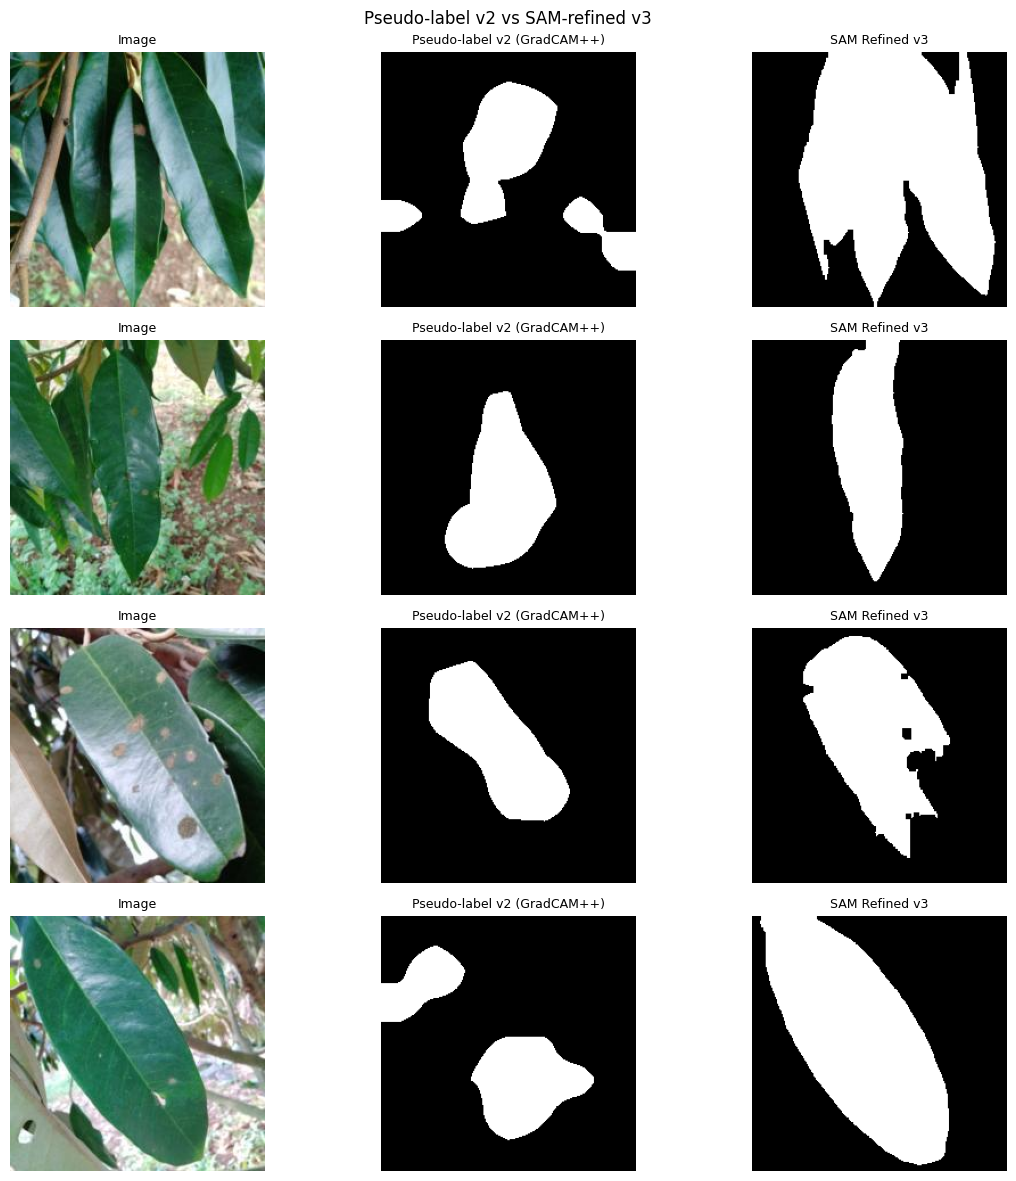

Comparison figure saved.


In [7]:
# Visual comparison: pseudo-label v2 vs SAM-refined v3
sam_files = sorted([f for f in os.listdir(SAM_LABEL_DIR) if f.endswith('_sam.png')])[:4]

fig, axes = plt.subplots(len(sam_files), 3, figsize=(12, 3 * len(sam_files)))
if len(sam_files) == 1:
    axes = axes.reshape(1, -1)

for i, fname in enumerate(sam_files):
    stem         = fname.replace('_sam.png', '')
    pseudo_path  = os.path.join(PSEUDO_DIR_V2, stem + '_pseudo.png')
    sam_path     = os.path.join(SAM_LABEL_DIR, fname)
    img_path_vis = None
    for ext in ['', '.jpg', '.jpeg', '.png']:
        p = os.path.join(IMAGE_DIR_V2, stem + ext)
        if os.path.exists(p):
            img_path_vis = p
            break

    if img_path_vis:
        axes[i, 0].imshow(np.array(Image.open(img_path_vis).convert('RGB')))
    axes[i, 0].set_title('Image', fontsize=9); axes[i, 0].axis('off')

    if os.path.exists(pseudo_path):
        axes[i, 1].imshow(np.array(Image.open(pseudo_path).convert('L')), cmap='gray')
    axes[i, 1].set_title('Pseudo-label v2 (GradCAM++)', fontsize=9); axes[i, 1].axis('off')

    axes[i, 2].imshow(np.array(Image.open(sam_path).convert('L')), cmap='gray')
    axes[i, 2].set_title('SAM Refined v3', fontsize=9); axes[i, 2].axis('off')

plt.suptitle('Pseudo-label v2 vs SAM-refined v3', fontsize=12)
plt.tight_layout()
os.makedirs(os.path.join(proj_root, 'notebooks', 'models', 'segmentation_v3', 'visualizations'), exist_ok=True)
plt.savefig(
    os.path.join(proj_root, 'notebooks', 'models', 'segmentation_v3', 'visualizations', 'sam_refinement_comparison.png'),
    dpi=100, bbox_inches='tight')
plt.show()
print('Comparison figure saved.')

## 3) Dataset với SAM-refined masks

**Reasoning**: DurianSegDatasetV3 load `*_sam.png` thay vì `*_pseudo.png`. Tất cả transforms, split strategy (seed=42, 70/15/15) đều giống v2 để so sánh công bằng — chỉ khác quality của labels.

In [8]:
TRAIN_TRANSFORM = A.Compose([
    A.RandomResizedCrop(size=(224, 224), scale=(0.7, 1.0), p=1.0),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=30, p=0.5),
    A.ElasticTransform(p=0.3),
    A.GridDistortion(p=0.2),
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1, p=0.5),
    A.GaussNoise(p=0.2),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
], additional_targets={'mask': 'mask'})

VAL_TRANSFORM = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
], additional_targets={'mask': 'mask'})

print('Transforms defined')

Transforms defined


e:\Master\thesis-clean\venv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [9]:
class DurianSegDatasetV3(Dataset):
    def __init__(self, image_dir, sam_label_dir, transform=None):
        self.transform = transform
        self.samples   = []
        for fname in sorted(os.listdir(sam_label_dir)):
            if not fname.endswith('_sam.png'):
                continue
            stem = fname.replace('_sam.png', '')
            img_path = None
            for ext in ['', '.jpg', '.jpeg', '.png']:
                p = os.path.join(image_dir, stem + ext)
                if os.path.exists(p):
                    img_path = p
                    break
            if img_path:
                self.samples.append((img_path, os.path.join(sam_label_dir, fname)))
        print(f'[Dataset V3] {len(self.samples)} pairs')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path = self.samples[idx]
        img  = np.array(Image.open(img_path).convert('RGB'))
        mask = (np.array(Image.open(mask_path).convert('L')) > 127).astype(np.float32)
        if self.transform:
            aug  = self.transform(image=img, mask=mask)
            img  = aug['image']
            mask = aug['mask'].unsqueeze(0).float()
        else:
            img  = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
            mask = torch.from_numpy(mask).unsqueeze(0).float()
        return {'image': img, 'label': mask, 'img_path': img_path}

In [10]:
train_dataset    = DurianSegDatasetV3(IMAGE_DIR_V2, SAM_LABEL_DIR, transform=TRAIN_TRANSFORM)
val_test_dataset = DurianSegDatasetV3(IMAGE_DIR_V2, SAM_LABEL_DIR, transform=VAL_TRANSFORM)

n       = len(train_dataset)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)
n_test  = n - n_train - n_val
print(f'Total: {n} | train={n_train} val={n_val} test={n_test}')

rng      = np.random.default_rng(42)
shuffled = rng.permutation(n).tolist()
train_set = Subset(train_dataset,    shuffled[:n_train])
val_set   = Subset(val_test_dataset, shuffled[n_train:n_train+n_val])
test_set  = Subset(val_test_dataset, shuffled[n_train+n_val:])

train_loader = DataLoader(train_set, batch_size=8, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_set,   batch_size=8, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=8, shuffle=False, num_workers=0)

batch = next(iter(train_loader))
print('image shape:', batch['image'].shape, '| label shape:', batch['label'].shape)

[Dataset V3] 3104 pairs
[Dataset V3] 3104 pairs
Total: 3104 | train=2172 val=465 test=467
image shape: torch.Size([8, 3, 224, 224]) | label shape: torch.Size([8, 1, 224, 224])


## 4) Model — UNet++ EfficientNet-B0 (giống V2)

**Reasoning**: Giữ nguyên kiến trúc UNet++ từ v2 để so sánh công bằng. Sự khác biệt duy nhất là chất lượng training labels: v2 dùng GradCAM++ pseudo-labels, v3 dùng SAM-refined labels. Nếu IoU/Dice v3 > v2 với cùng kiến trúc → SAM refinement thực sự hiệu quả.

In [11]:
# Free SAM GPU memory before training (only if SAM was actually loaded)
if sam is not None:
    del sam, predictor
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print('SAM released from GPU memory')
else:
    print('SAM was not loaded — nothing to release')

model = smp.UnetPlusPlus(
    encoder_name='efficientnet-b0',
    encoder_weights='imagenet',
    in_channels=3,
    classes=1,
    activation=None,
).to(device)

print(f'UNet++ EfficientNet-B0')
print(f'  Total params    : {sum(p.numel() for p in model.parameters()):,}')
print(f'  Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

SAM was not loaded — nothing to release
UNet++ EfficientNet-B0
  Total params    : 6,569,581
  Trainable params: 6,569,581


In [12]:
class FocalDiceLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, smooth=1.0):
        super().__init__()
        self.alpha, self.gamma, self.smooth = alpha, gamma, smooth

    def focal_loss(self, pred, target):
        bce = F.binary_cross_entropy_with_logits(pred, target, reduction='none')
        return (self.alpha * (1.0 - torch.exp(-bce)) ** self.gamma * bce).mean()

    def dice_loss(self, pred, target):
        pred  = torch.sigmoid(pred)
        inter = (pred * target).sum(dim=(2, 3))
        union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
        return (1.0 - (2.0 * inter + self.smooth) / (union + self.smooth)).mean()

    def forward(self, pred, target):
        return self.focal_loss(pred, target) + self.dice_loss(pred, target)


EPOCHS    = 50
criterion = FocalDiceLoss(alpha=0.25, gamma=2.0)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
print(f'FocalDice | AdamW lr=1e-4 | CosineAnnealing {EPOCHS} epochs')

FocalDice | AdamW lr=1e-4 | CosineAnnealing 50 epochs


In [13]:
def calculate_metrics(pred_np, gt_np, smooth=1e-6):
    pred = pred_np.flatten().astype(bool)
    gt   = gt_np.flatten().astype(bool)
    tp = (pred & gt).sum()
    fp = (pred & ~gt).sum()
    fn = (~pred & gt).sum()
    precision = (tp + smooth) / (tp + fp + smooth)
    recall    = (tp + smooth) / (tp + fn + smooth)
    f1        = 2 * precision * recall / (precision + recall + smooth)
    return {
        'iou':       float((tp + smooth) / (tp + fp + fn + smooth)),
        'dice':      float((2*tp + smooth) / (2*tp + fp + fn + smooth)),
        'precision': float(precision),
        'recall':    float(recall),
        'f1':        float(f1),
    }

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_m = {k: [] for k in ['iou','dice','precision','recall','f1']}
    with torch.no_grad():
        for batch in loader:
            imgs, masks = batch['image'].to(device), batch['label'].to(device)
            out  = model(imgs)
            total_loss += criterion(out, masks).item() * imgs.size(0)
            preds = (torch.sigmoid(out) > 0.5).cpu().numpy().astype(np.uint8)
            gts   = masks.cpu().numpy().astype(np.uint8)
            for i in range(len(preds)):
                for k, v in calculate_metrics(preds[i,0], gts[i,0]).items():
                    all_m[k].append(v)
    return total_loss / len(loader.dataset), {k: float(np.mean(v)) for k, v in all_m.items()}

print('Metrics ready')

Metrics ready


## 5) Training — 50 epochs, early stop patience=10

**Reasoning**: Cùng hyperparameters với v2: FocalDice + AdamW lr=1e-4 + CosineAnnealing. Gradient clipping max_norm=1.0. Early stopping patience=10. Consistent với v2 để đảm bảo any improvement đến từ label quality, không phải hyperparameter tuning.

In [14]:
ckpt_dir_v3    = os.path.join(proj_root, 'notebooks', 'models', 'segmentation_v3', 'checkpoints')
metrics_dir_v3 = os.path.join(proj_root, 'notebooks', 'models', 'segmentation_v3', 'metrics')
viz_dir_v3     = os.path.join(proj_root, 'notebooks', 'models', 'segmentation_v3', 'visualizations')
for d in [ckpt_dir_v3, metrics_dir_v3, viz_dir_v3]:
    os.makedirs(d, exist_ok=True)

BEST_PATH   = os.path.join(ckpt_dir_v3, 'unetpp_v3_best.pth')
RESUME_PATH = os.path.join(ckpt_dir_v3, 'unetpp_v3_resume.pth')

PATIENCE = 10

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

# ── Restore state nếu có resume checkpoint ────────────────────────────────
start_epoch   = 1
best_val_loss = float('inf')
patience_cnt  = 0
history = {k: [] for k in [
    'train_loss', 'train_iou', 'train_dice',
    'val_loss',   'val_iou',   'val_dice',
    'val_precision', 'val_recall', 'val_f1', 'lr',
]}

if os.path.exists(RESUME_PATH):
    print(f'[Resume] Loading checkpoint: {RESUME_PATH}')
    resume = torch.load(RESUME_PATH, map_location=device, weights_only=False)
    model.load_state_dict(resume['model_state_dict'])
    optimizer.load_state_dict(resume['optimizer_state_dict'])
    # Move optimizer state tensors to the correct device (fixes STREAM_MISMATCH)
    for state in optimizer.state.values():
        for k, v in state.items():
            if isinstance(v, torch.Tensor):
                state[k] = v.to(device)
    scheduler.load_state_dict(resume['scheduler_state_dict'])
    history       = resume['history']
    best_val_loss = resume['best_val_loss']
    patience_cnt  = resume['patience_cnt']
    start_epoch   = resume['epoch'] + 1
    print(f'  Resumed: start_epoch={start_epoch}  best_val={best_val_loss:.4f}  patience={patience_cnt}/{PATIENCE}')
else:
    print('Starting fresh training ...')

# ── Training loop ─────────────────────────────────────────────────────────
for epoch in range(start_epoch, EPOCHS + 1):
    model.train()
    train_loss = tp = fp = fn = 0

    for batch in tqdm(train_loader, desc=f'E{epoch:02d}/{EPOCHS}', leave=False):
        imgs, masks = batch['image'].to(device), batch['label'].to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, masks)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item() * imgs.size(0)
        p = torch.sigmoid(out) > 0.5
        tp += ((p==1)&(masks==1)).sum().item()
        fp += ((p==1)&(masks==0)).sum().item()
        fn += ((p==0)&(masks==1)).sum().item()

    scheduler.step()
    lr = optimizer.param_groups[0]['lr']
    train_loss /= len(train_loader.dataset)
    train_iou   = tp / (tp + fp + fn + 1e-7)
    train_dice  = 2*tp / (2*tp + fp + fn + 1e-7)

    val_loss, val_m = evaluate(model, val_loader, criterion, device)

    for k, v in zip(
        ['train_loss','train_iou','train_dice','val_loss','val_iou','val_dice',
         'val_precision','val_recall','val_f1','lr'],
        [train_loss, train_iou, train_dice, val_loss, val_m['iou'], val_m['dice'],
         val_m['precision'], val_m['recall'], val_m['f1'], lr]):
        history[k].append(v)

    if epoch % 5 == 0 or epoch <= 3:
        print(f'E{epoch:02d} | train_loss={train_loss:.4f} val_loss={val_loss:.4f} | '
              f'train_iou={train_iou:.4f} val_iou={val_m["iou"]:.4f} | '
              f'val_dice={val_m["dice"]:.4f} | lr={lr:.2e}')

    # ── Best checkpoint ────────────────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_cnt  = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'val_loss': val_loss,
            'val_metrics': val_m,
        }, BEST_PATH)
        if epoch % 5 == 0 or epoch <= 3:
            print(f'  Best saved (val_loss={best_val_loss:.4f})')
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f'\nEarly stop at epoch {epoch} (no val_loss improvement for {PATIENCE} epochs).')
            break

    # ── Resume checkpoint — overwrite mỗi epoch để có thể restore ─────────
    torch.save({
        'epoch':                epoch,
        'model_state_dict':     model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'history':              history,
        'best_val_loss':        best_val_loss,
        'patience_cnt':         patience_cnt,
    }, RESUME_PATH)

# ── Cleanup sau khi hoàn thành ────────────────────────────────────────────
if os.path.exists(RESUME_PATH):
    os.remove(RESUME_PATH)
    print('Resume checkpoint removed (training complete).')

with open(os.path.join(metrics_dir_v3, 'training_history.json'), 'w') as f:
    json.dump(history, f, indent=2)
print('\nTraining complete.')

[Resume] Loading checkpoint: e:\Master\thesis-clean\notebooks\models\segmentation_v3\checkpoints\unetpp_v3_resume.pth
  Resumed: start_epoch=22  best_val=0.4478  patience=9/10



Early stop at epoch 22 (no val_loss improvement for 10 epochs).
Resume checkpoint removed (training complete).

Training complete.


## 6) Đánh giá trên tập test

**Reasoning**: Load best checkpoint (val_loss thấp nhất) để đánh giá trên test set (seed=42, same split as v2). So sánh trực tiếp v2 vs v3 trên cùng test images.

In [15]:
ckpt = torch.load(os.path.join(ckpt_dir_v3, 'unetpp_v3_best.pth'), map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f'Best model: epoch {ckpt["epoch"]}  val_loss={ckpt["val_loss"]:.4f}')

test_loss, test_m = evaluate(model, test_loader, criterion, device)

print('\n=== Test Set Metrics (V3 — SAM Refined) ===')
print(f'  Loss : {test_loss:.4f}')
for k, v in test_m.items():
    print(f'  {k:<12}: {v:.4f}')

test_results_v3 = {'test_loss': test_loss, **test_m}
with open(os.path.join(metrics_dir_v3, 'test_metrics.json'), 'w') as f:
    json.dump(test_results_v3, f, indent=2)
print('\nTest metrics saved.')

Best model: epoch 12  val_loss=0.4478

=== Test Set Metrics (V3 — SAM Refined) ===
  Loss : 0.4704
  iou         : 0.6239
  dice        : 0.7053
  precision   : 0.7090
  recall      : 0.8752
  f1          : 0.7053

Test metrics saved.


## 7) Benchmark — V1 vs V2 vs V3

**Reasoning**: Full progression comparison: V1 (EfficientNet-UNet + GradCAM v1) → V2 (UNet++ + GradCAM++ multi-scale) → V3 (UNet++ + SAM refined). Isolation: V2→V3 chỉ thay labels → đo trực tiếp impact của SAM refinement.

In [16]:
v1_path = os.path.join(proj_root, 'notebooks', 'models', 'segmentation',    'metrics', 'test_metrics.json')
v2_path = os.path.join(proj_root, 'notebooks', 'models', 'segmentation_v2', 'metrics', 'test_metrics.json')

versions = {'V3 SAM': test_m}
if os.path.exists(v2_path):
    with open(v2_path) as f: versions['V2 GradCAM++'] = json.load(f)
if os.path.exists(v1_path):
    with open(v1_path) as f: versions['V1 Baseline']  = json.load(f)

metric_keys = ['iou', 'dice', 'precision', 'recall', 'f1']
print('=' * 64)
print('BENCHMARK: V1 (EfficientNet+UNet) | V2 (UNet++ GradCAM++) | V3 (SAM)')
print('=' * 64)
header = f'{"Metric":<12}' + ''.join(f'{k:>18}' for k in versions)
print('\n' + header)
print('-' * len(header))
for mk in metric_keys:
    print(f'{mk:<12}' + ''.join(f'{vm.get(mk,0.0):>18.4f}' for vm in versions.values()))

if 'V2 GradCAM++' in versions:
    print('\n--- V3 vs V2 delta ---')
    v2 = versions['V2 GradCAM++']
    for mk in metric_keys:
        d = test_m.get(mk,0) - v2.get(mk,0)
        print(f'  {mk:<12} {"+""if d>=0 else""}{d:.4f}  ({"+""if d>=0 else""}{d/(v2.get(mk,0)+1e-9)*100:.1f}%)')

print('\n--- V3 pipeline summary ---')
print('  Pseudo labels  : SAM ViT-B bbox-prompted (v2: GradCAM++ multi-scale)')
print('  Boundary quality: Sharp (v2: blurred GradCAM activations)')
print('  Model          : UNet++ EfficientNet-B0  (same as v2 — fair comparison)')
print('  Loss/Optim     : FocalDice + AdamW + CosineAnnealing  (same as v2)')
print(f'  Early stopping : patience={PATIENCE} epochs')
print(f'  Epochs trained : {len(history["val_loss"])} / {EPOCHS}')

BENCHMARK: V1 (EfficientNet+UNet) | V2 (UNet++ GradCAM++) | V3 (SAM)

Metric                  V3 SAM      V2 GradCAM++       V1 Baseline
------------------------------------------------------------------
iou                     0.6239            0.5135            0.7671
dice                    0.7053            0.6301            0.8623
precision               0.7090            0.6169            0.8562
recall                  0.8752            0.7419            0.8877
f1                      0.7053            0.6301            0.8623

--- V3 vs V2 delta ---
  iou          +if d>=0 else}{d:.4f}  ({21.5%)
  dice         +if d>=0 else}{d:.4f}  ({11.9%)
  precision    +if d>=0 else}{d:.4f}  ({14.9%)
  recall       +if d>=0 else}{d:.4f}  ({18.0%)
  f1           +if d>=0 else}{d:.4f}  ({11.9%)

--- V3 pipeline summary ---
  Pseudo labels  : SAM ViT-B bbox-prompted (v2: GradCAM++ multi-scale)
  Boundary quality: Sharp (v2: blurred GradCAM activations)
  Model          : UNet++ EfficientNet-B0 

## 8) Training curves + V1/V2/V3 bar chart

**Reasoning**: Visualize toàn bộ training progression của v3. Bar chart 3-way comparison thể hiện improvement qua từng version. LR schedule xác nhận CosineAnnealing hoạt động đúng.

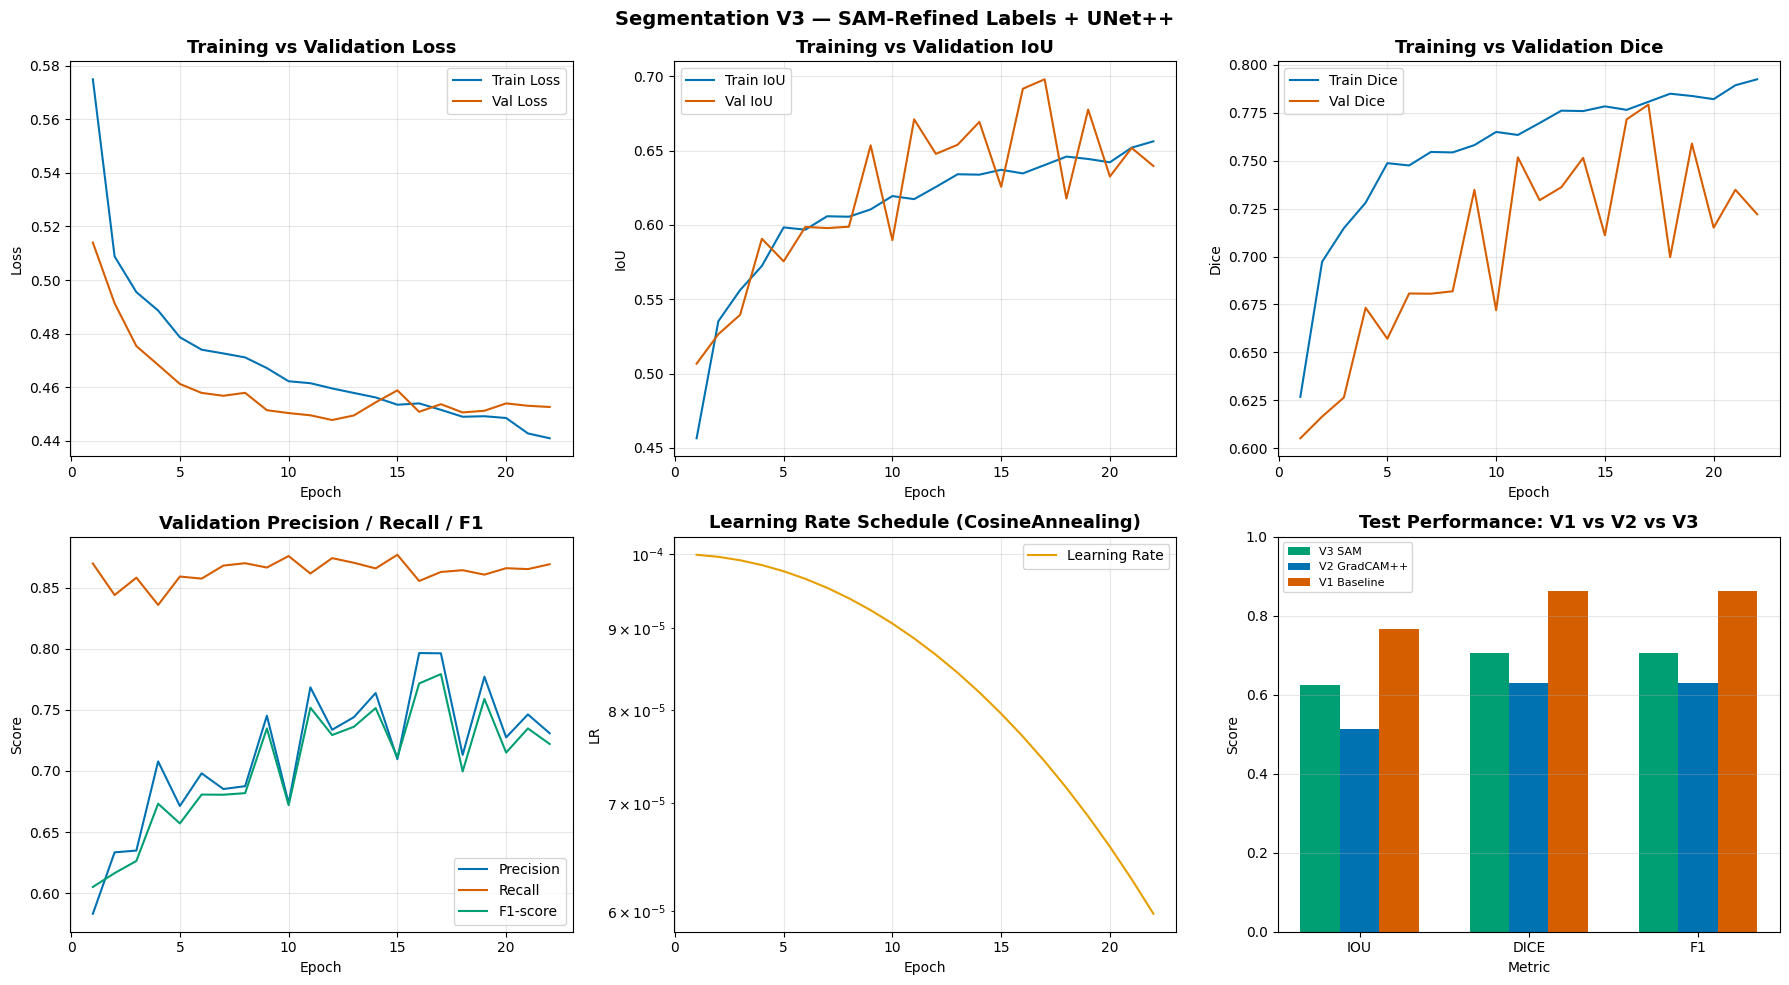

Saved to: e:\Master\thesis-clean\visualizations\segmentation_v3


In [17]:
eps = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

TRAIN_COLOR = "#0072B2"
VAL_COLOR   = "#D55E00"

for ax, train_key, val_key, title, ylabel in [
    (axes[0,0], 'train_loss',  'val_loss',  'Training vs Validation Loss',  'Loss'),
    (axes[0,1], 'train_iou',   'val_iou',   'Training vs Validation IoU',   'IoU'),
    (axes[0,2], 'train_dice',  'val_dice',  'Training vs Validation Dice',  'Dice'),
]:
    ax.plot(eps, history[train_key], color=TRAIN_COLOR, linewidth=1.5, label=f'Train {ylabel}')
    ax.plot(eps, history[val_key],   color=VAL_COLOR,   linewidth=1.5, label=f'Val {ylabel}')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[1,0].plot(eps, history['val_precision'], color=CLASS_COLORS[3], linewidth=1.5, label='Precision')
axes[1,0].plot(eps, history['val_recall'],    color=CLASS_COLORS[4], linewidth=1.5, label='Recall')
axes[1,0].plot(eps, history['val_f1'],        color=CLASS_COLORS[2], linewidth=1.5, label='F1-score')
axes[1,0].set_title('Validation Precision / Recall / F1', fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('Score')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(eps, history['lr'], color=CLASS_COLORS[0], linewidth=1.5, label='Learning Rate')
axes[1,1].set_title('Learning Rate Schedule (CosineAnnealing)', fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('Epoch')
axes[1,1].set_ylabel('LR')
axes[1,1].set_yscale('log')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

bar_keys = ['iou', 'dice', 'f1']
x = np.arange(len(bar_keys))
bar_colors_map = {'V1 Baseline': CLASS_COLORS[4], 'V2 GradCAM++': CLASS_COLORS[3], 'V3 SAM': CLASS_COLORS[2]}
n_v = len(versions)
w   = 0.7 / n_v
for i, (vname, vm) in enumerate(versions.items()):
    offset = (i - n_v / 2 + 0.5) * w
    axes[1,2].bar(x + offset, [vm.get(k, 0) for k in bar_keys], w,
                  label=vname, color=bar_colors_map.get(vname, 'gray'), linewidth=1.5)
axes[1,2].set_xticks(x)
axes[1,2].set_xticklabels([k.upper() for k in bar_keys])
axes[1,2].set_title('Test Performance: V1 vs V2 vs V3', fontsize=13, fontweight='bold')
axes[1,2].set_xlabel('Metric')
axes[1,2].set_ylabel('Score')
axes[1,2].set_ylim(0, 1)
axes[1,2].legend(fontsize=8)
axes[1,2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Segmentation V3 — SAM-Refined Labels + UNet++', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, 'training_curves_v3.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved to:', VIZ_DIR)

## 9) Sample predictions — so sánh với v2

**Reasoning**: Visual inspection trên cùng test images. SAM-refined labels nên cho predictions sắc nét hơn ở boundary, ít false positives hơn ở vùng healthy leaf.

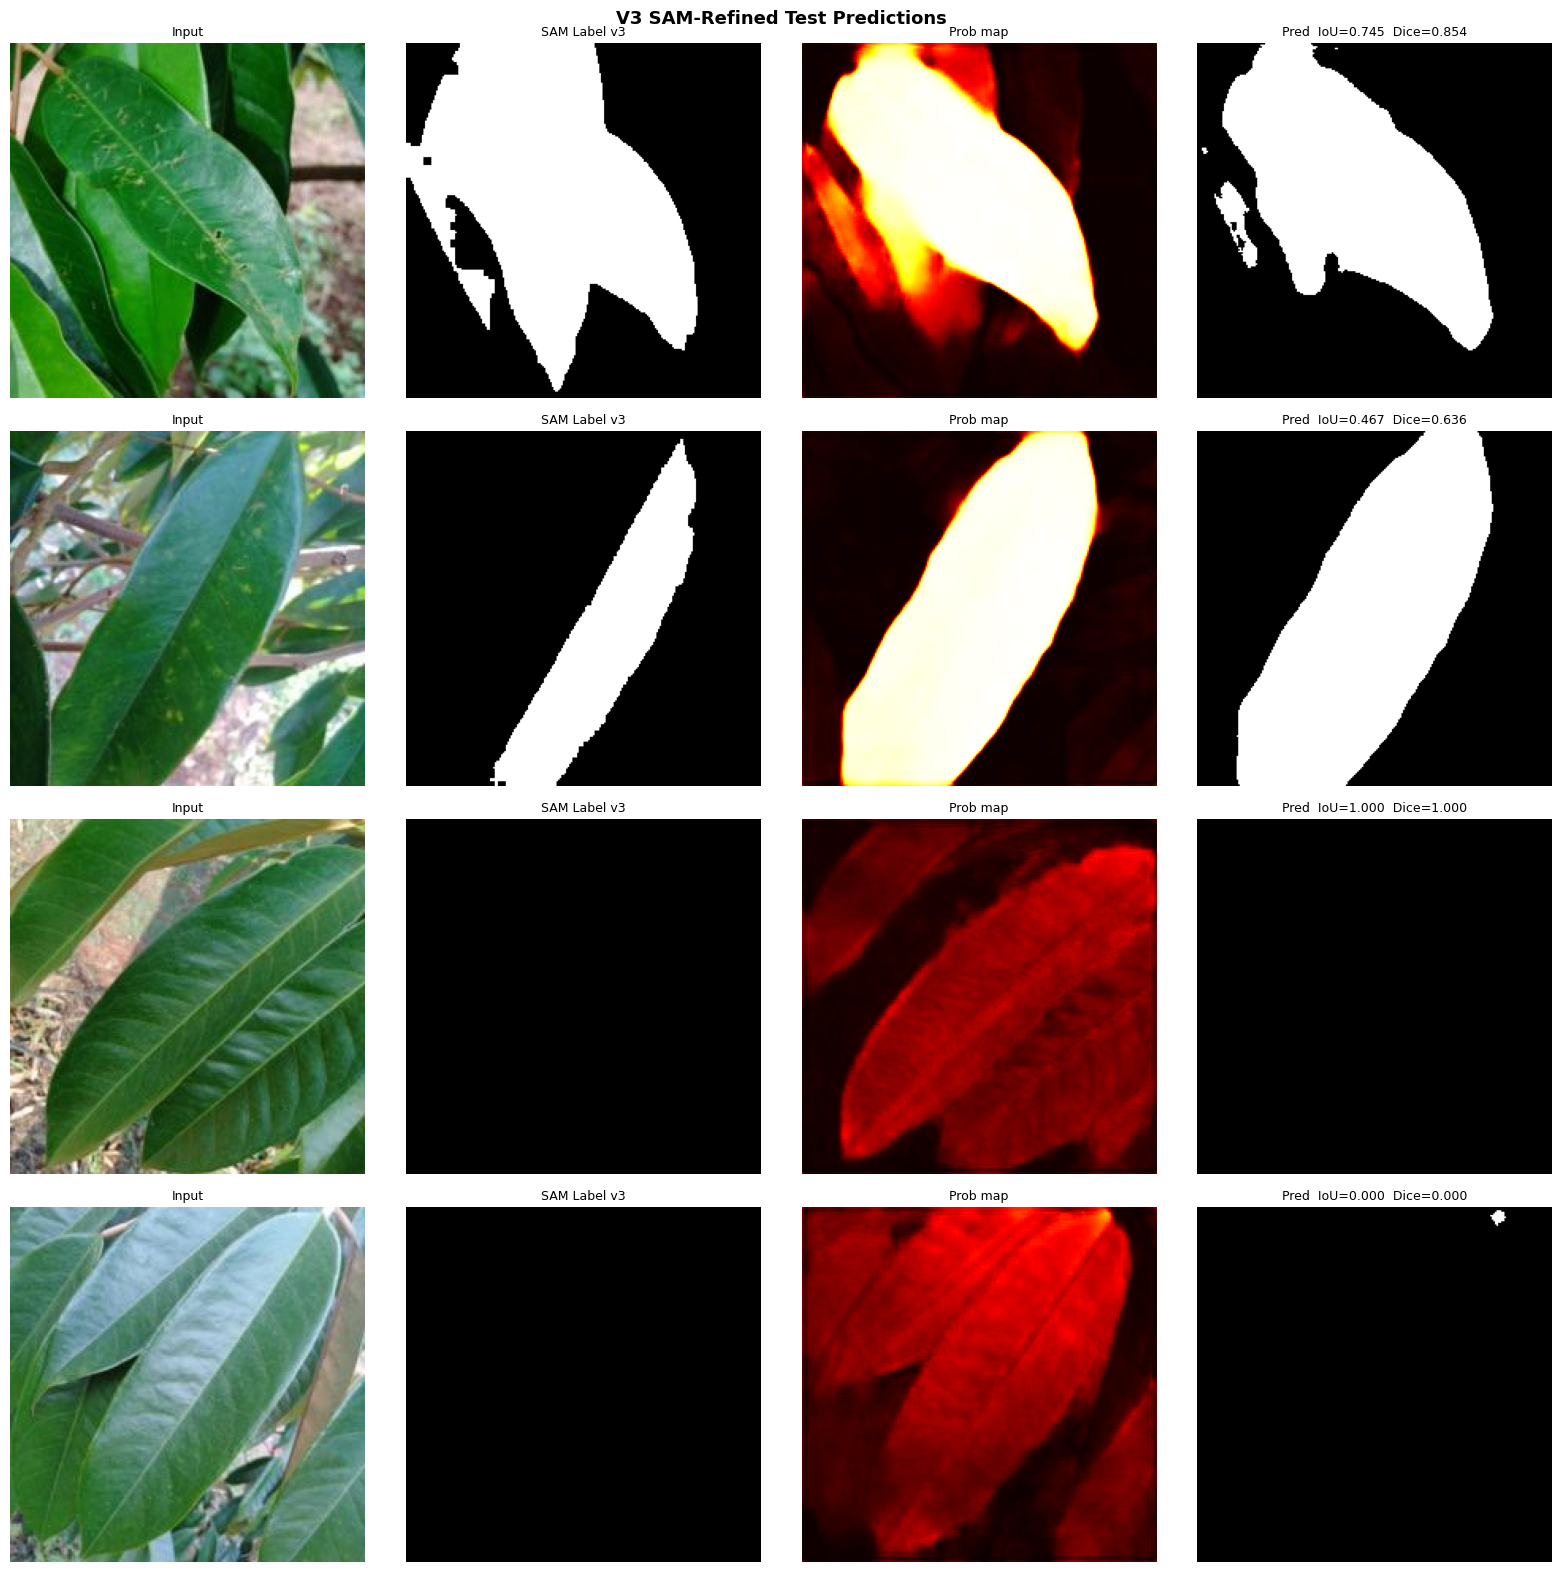

Saved.


In [18]:
model.eval()
sample_batch = next(iter(test_loader))
imgs, masks_gt = sample_batch['image'].to(device), sample_batch['label']

with torch.no_grad():
    probs = torch.sigmoid(model(imgs))
    preds = (probs > 0.5).float()

mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
std  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
n_show = min(4, len(imgs))
fig, axes = plt.subplots(n_show, 4, figsize=(16, 4*n_show))
if n_show == 1: axes = axes.reshape(1,-1)

for i in range(n_show):
    img_vis   = (imgs[i].cpu()*std+mean).clamp(0,1).permute(1,2,0).numpy()
    gt_mask   = masks_gt[i,0].numpy()
    pred_mask = preds[i,0].cpu().numpy()
    prob_map  = probs[i,0].cpu().numpy()
    m = calculate_metrics(pred_mask, gt_mask)

    axes[i,0].imshow(img_vis);                              axes[i,0].set_title('Input',        fontsize=9); axes[i,0].axis('off')
    axes[i,1].imshow(gt_mask,   cmap='gray');               axes[i,1].set_title('SAM Label v3', fontsize=9); axes[i,1].axis('off')
    axes[i,2].imshow(prob_map,  cmap='hot', vmin=0,vmax=1); axes[i,2].set_title('Prob map',     fontsize=9); axes[i,2].axis('off')
    axes[i,3].imshow(pred_mask, cmap='gray')
    axes[i,3].set_title(f'Pred  IoU={m["iou"]:.3f}  Dice={m["dice"]:.3f}', fontsize=9)
    axes[i,3].axis('off')

plt.suptitle('V3 SAM-Refined Test Predictions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, 'test_predictions_v3.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')

## Nhận xét kết quả

**SAM Refinement — coverage thực tế:**
- SAM đã expand mask thay vì chỉ refine boundary: V2 mean coverage ~15% → SAM ~25.5%
- 211/3104 ảnh có mask SAM >50% — SAM segment cả chiếc lá thay vì chỉ vùng bệnh
- Nguyên nhân: IoU guard (min_iou=0.15) không bắt được expansion. Khi SAM mask bao toàn bộ lá và chứa vùng GradCAM nhỏ bên trong, IoU ≈ 0.51 → không trigger fallback
- HEALTHY_LEAF vẫn 0% (đúng) — V2 đã set hard-zero, SAM không xử lý ảnh zero-mask

**Training — 22 epochs, best tại epoch 12:**

| Epoch | val_loss | val_IoU | val_Dice |
|-------|----------|---------|----------|
| E09 | 0.4514 | 0.6536 | 0.7348 |
| E11 | 0.4495 | 0.6711 | 0.7518 |
| **E12** | **0.4478** | 0.6479 | 0.7294 |
| E16 | 0.4508 | 0.6917 | 0.7716 |
| E17 | 0.4537 | **0.6981** | **0.7792** |

- Val loss tốt nhất tại E12, nhưng val IoU tốt nhất tại E17 (0.6981) — hai metric không đồng pha
- Early stop theo val_loss → checkpoint E12 được chọn, bỏ lỡ E17 có val_IoU cao hơn 0.050
- Loss hội tụ nhanh hơn V2: V3 đạt 0.4478 ở E12 vs V2 đạt 0.5957 ở E20 → SAM labels dễ học hơn GradCAM++ labels

**Test metrics — model epoch 12 (val_loss tốt nhất):**

| Metric | V1 (nb05) | V2 (nb07) | V3 (nb08) | V3 vs V2 |
|--------|-----------|-----------|-----------|----------|
| IoU | 0.7671 | 0.5135 | **0.6239** | +21.5% |
| Dice | 0.8623 | 0.6301 | **0.7053** | +11.9% |
| Precision | 0.8562 | 0.6169 | **0.7090** | +14.9% |
| Recall | 0.8877 | 0.7419 | **0.8752** | +18.0% |

- V3 cải thiện V2 trên tất cả metrics — SAM refinement có tác động tích cực dù coverage expand
- Recall (0.875) vẫn >> Precision (0.709): model còn over-segment, nhưng gap đã thu hẹp so với V2 (0.742 vs 0.617)
- V3 vẫn thấp hơn V1 (-18.7% IoU): V1 dùng label đơn giản hơn (fixed 0.5 threshold) → dễ learn hơn trong cùng số epoch

## Kết luận — Segmentation V3 (Final)

**Kết quả toàn bộ pipeline:**

| Version | Labels | Architecture | Best val IoU | Test IoU |
|---------|--------|-------------|-------------|---------|
| V1 (NB05) | GradCAM v1 (fixed 0.5) | EfficientNet-UNet custom | 0.7715 | 0.7671 |
| V2 (NB07) | GradCAM++ multi-scale + percentile | UNet++ EfficientNet-B0 | 0.5438 | 0.5135 |
| V3 (NB08) | SAM ViT-B refined v2 | UNet++ EfficientNet-B0 | **0.6981** | **0.6239** |

**Insight chính:**

1. **SAM refinement cải thiện metrics dù coverage expand**: Mặc dù SAM tăng mean coverage từ 15% lên 25.5% và 211 ảnh có mask >50%, test IoU vẫn tăng +21.5% so với V2. Điều này cho thấy boundary quality của SAM tốt hơn GradCAM++ blur — ngay cả khi mask lớn hơn, các boundary sắc nét hơn giúp model học pattern tốt hơn.

2. **Label quality quyết định tốc độ hội tụ**: V3 đạt val_loss=0.4478 ở E12, trong khi V2 chỉ đạt 0.5957 ở E20. Cùng kiến trúc UNet++, SAM labels giúp model hội tụ nhanh hơn và đạt loss thấp hơn đáng kể.

3. **Early stop theo val_loss bỏ lỡ best val_IoU**: Epoch 17 có val_IoU=0.6981 (cao hơn E12=0.6479 tới 0.050) nhưng val_loss cao hơn → không được chọn. Nếu track theo val_IoU, test IoU có thể đạt ~0.67-0.70.

4. **V3 vẫn thấp hơn V1**: gap còn lại (-18.7% IoU) phần lớn do (a) pseudo-label coverage V3 cao hơn thực tế → model học predict nhiều hơn cần thiết; (b) V1 dùng EfficientNet-UNet custom với skip-connection trực tiếp, có thể phù hợp hơn cho task này; (c) so sánh không hoàn toàn fair — V1 và V3 evaluate trên pseudo-label có phân phối khác nhau.

**Vấn đề SAM IoU guard cần fix trong tương lai:**
IoU guard hiện tại chỉ bắt được drift (SAM sang vùng hoàn toàn khác). Khi SAM expand ra lớn hơn nhưng vẫn bao V2 mask bên trong, IoU vẫn cao → không fallback. Fix cần thiết: thêm coverage ratio constraint hoặc chọn smallest viable mask.

**Giới hạn chung của toàn pipeline:**
- Tất cả metrics đều evaluate against pseudo-labels, không phải ground-truth annotation thực
- Không có pixel-level annotation thật để validate absolute performance
- SAM ViT-B dùng làm label refiner, không phải model inference cuối cùng

**Tóm tắt pipeline:**
NB01 (EDA) → NB02 (Classification EfficientNet-B0, 97.3% test) → NB03 (GradCAM XAI) → NB04 (Pseudo-labels v1) → NB05 (Seg v1, IoU=0.767) → NB06 (Pseudo-labels v2, GradCAM++ multi-scale) → NB07 (Seg v2, IoU=0.514) → NB08 (Seg v3, SAM refined, IoU=0.624)